In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Import Liberaries**

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras

# **Masked and Un-Masked Data splitting**

In [6]:
masked = "/content/drive/MyDrive/data/with_mask"
unmasked = "/content/drive/MyDrive/data/without_mask"

images_mask = os.listdir(masked)
images_nomask = os.listdir(unmasked)

print("Mask Images :", len(images_mask))
print("No Mask Images :", len(images_nomask))

Mask Images : 3725
No Mask Images : 3828


# **Sample Data M - UnM Visulization**

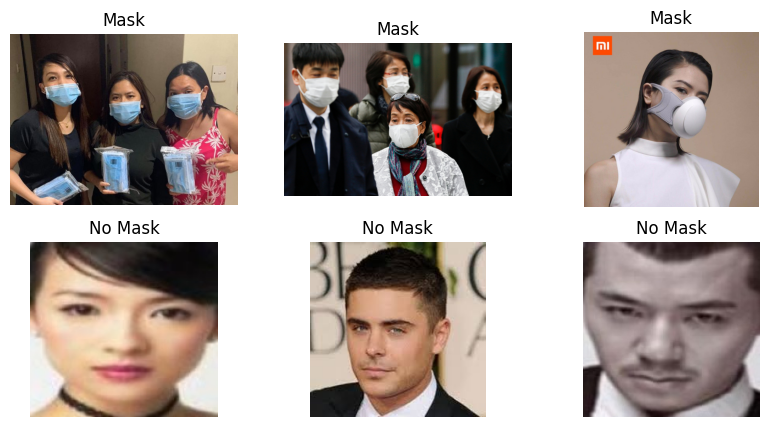

In [7]:
plt.figure(figsize=(10,5))

for i in range(3):

    img = cv2.imread(os.path.join(masked, images_mask[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Mask")

for i in range(3):

    img = cv2.imread(os.path.join(unmasked, images_nomask[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+4)
    plt.imshow(img)
    plt.axis("off")
    plt.title("No Mask")

plt.show()

# **Data Splitting**

In [8]:
X = []
y = []

### **Masked:**

In [ ]:
for file in tqdm(images_mask):

    path = os.path.join(masked, file)

    img = cv2.imread(path)

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img,(224,224))

    X.append(img)

    y.append(0)

  1%|          | 38/3725 [00:08<14:14,  4.31it/s]

### **Masked + UnMasked**

In [ ]:
for file in tqdm(images_nomask):

    path = os.path.join(unmasked, file)

    img = cv2.imread(path)

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img,(224,224))

    X.append(img)

    y.append(1)

### **Append Values**

In [ ]:
np.save("X2.npy",X)

np.save("y2.npy",y)

In [ ]:
X = np.load("X.npy")

y = np.load("y.npy")

In [ ]:
X = np.array(X,dtype=np.uint8)

y = np.array(y)

print(X.shape)

print(y.shape)

# **Train Test Split Validation**

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    shuffle=True,
    stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True,
    stratify=y_temp
)

# **Building CNN**

In [ ]:
from tensorflow import keras
import tensorflow as tf

base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

kerasModel = keras.Sequential([
    keras.Input(shape=(224,224,3)),

    keras.layers.Rescaling(1./255),

    base_model,

    keras.layers.GlobalAveragePooling2D(),

    keras.layers.Dropout(0.3),

    keras.layers.Dense(1, activation="sigmoid")
])

In [ ]:
kerasModel.summary()

In [ ]:
kerasModel.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = kerasModel.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=128,
)

In [ ]:
kerasModel.save("MaskDetector.keras")
print('Saved..!')

In [ ]:
newModel = keras.models.load_model("MaskDetector.keras")

In [ ]:
index = 1

img = X_test[index]

plt.imshow(img)

plt.axis("off")

plt.show()

In [ ]:
img = np.expand_dims(img, axis=0)

prediction = newModel.predict(img)

print(prediction)

In [ ]:
if prediction[0][0] >= 0.5:

    print("No Mask")

else:

    print("Mask")

In [ ]:
loss, accuracy = newModel.evaluate(X_test, y_test)

print("Loss :", loss)

print("Accuracy :", accuracy)